# Simons CMAP API — a short, visual tour
### Discovery → retrieval → server-side analysis → colocalization

*Mohammad D. Ashkezari, E. Virginia Armbrust*

*BCI-EDGE, 21 September 2026*

This notebook demonstrates the mechanics of Simons CMAP: how datasets are discovered, retrieved, reduced on the server, and colocalized through one API. The scientific companion, `BCI_EDGE_CaseStudy.ipynb`, uses the same interface to build a complete analysis.

The Barro Colorado Island (BCI) tables used below — the 50-ha census and the STRI meteorological record — were harmonized into the CMAP catalog through the platform's standard ingestion pipeline; the providers are credited under Data sources.

**Requirements.** `pip install -U pycmap` (0.2.21 or later) and a free API key from [simonscmap.com](https://simonscmap.com). The key is stored locally after first use.


In [61]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import pycmap

# First use on a machine: pycmap.API(token="YOUR_API_KEY") stores the key locally.
api = pycmap.API()

FIGS = Path("figs_api_tour")
FIGS.mkdir(exist_ok=True)
C = {
    "blue": "#0072B2",
    "orange": "#E69F00",
    "vermillion": "#D55E00",
    "green": "#009E73",
    "gray": "#6F6F6F",
    "black": "#222222",
}
mpl.rcParams.update(
    {
        "figure.dpi": 150,
        "savefig.dpi": 600,
        "savefig.bbox": "tight",
        "font.family": "DejaVu Sans",
        "font.size": 10.5,
        "axes.titlesize": 12,
        "axes.titleweight": "semibold",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "legend.frameon": False,
        "axes.grid": False,
        "lines.solid_capstyle": "round",
        "pdf.fonttype": 42,
        "svg.fonttype": "none",
    }
)


def savepub(fig, stem):
    fig.savefig(FIGS / f"{stem}.png", dpi=600, bbox_inches="tight", facecolor="white")


def compact(df, n=8):
    return df.head(n).style.hide(axis="index")

## 1. Discover what exists

`get_catalog()` returns the variable-level catalog. `search_catalog()` adds semantic discovery, so the user does not need to know an exact SQL table name before beginning.


In [63]:
cat = api.get_catalog()
print(f"Catalog: {cat.Table_Name.nunique():,} tables; {len(cat):,} variable records")

Catalog: 559 tables; 12,807 variable records


In [157]:
bci = api.search_catalog("no3 model")
cols = [
    c
    for c in [
        "Long_Name",
        "Variable",
        "Table_Name",
        "Unit",
        "Temporal_Resolution",
        "Spatial_Resolution",
        "Time_Min",
        "Time_Max",
    ]
    if c in bci.columns
]
compact(bci[cols], n=12)

Long_Name,Variable,Table_Name,Unit,Temporal_Resolution,Spatial_Resolution,Time_Min,Time_Max
NO3 concentration (climatology),NO3_darwin_clim,tblDarwin_Nutrient_Climatology,mmol N/,Monthly Climatology,1/2Â° X 1/2Â°,nan,nan
Mole concentration of Nitrate in sea water,NO3,tblPisces_NRT,mmol/m^3,Weekly,1/2Â° X 1/2Â°,2011-12-31T00:00:00.000Z,2019-04-27T00:00:00.000Z
Mole Concentration of Nitrate in Sea Water,no3,tblPisces_Forecast,mmol/m^3,Daily,1/4Â° X 1/4Â°,2019-01-01T00:00:00.000Z,2021-05-07T00:00:00.000Z
Mole Concentration of Nitrate in Sea Water,no3,tblPisces_Forecast_cl1,mmol/m^3,Daily,1/4Â° X 1/4Â°,2020-11-01T12:00:00.000Z,2024-03-08T12:00:00.000Z
Mole Concentration of Nitrate in Sea Water,no3,tblPisces_Forecast_Nutrients,mmol/m^3,Daily,1/4Â° X 1/4Â°,2022-01-01T12:00:00.000Z,2025-07-18T12:00:00.000Z


## 2. Retrieve a complete dataset

The BCI monthly meteorological table is small enough to retrieve directly. Larger datasets are normally subset server-side.


In [158]:
met = api.get_dataset("tblBCI_Met_Monthly").head()
print(f"BCI monthly meteorology: {len(met):,} rows × {met.shape[1]} columns")
compact(met, n=6)

BCI monthly meteorology: 5 rows × 33 columns


time,lat,lon,station,sensor_elevation,precip_total,precip_total_elec,air_temp_mean_elec,air_temp_max_abs_elec,air_temp_max_avg_elec,air_temp_min_abs_elec,air_temp_min_avg_elec,air_temp_max_abs_man,air_temp_max_avg_man,air_temp_min_abs_man,air_temp_min_avg_man,rel_humidity_noon_man,rel_humidity_mean_elec,wind_speed_mean,wind_speed_max,wind_speed_max_avg,wind_dir_mean,solar_rad_daily_total,solar_rad_max_abs,solar_rad_max_avg,air_pressure_mean,pet_total,runoff_total,runoff_mm_eq,soil_h2o_wet_0_10cm,soil_h2o_wet_30_40cm,soil_h2o_dry_0_10cm,soil_h2o_dry_30_40cm
1925-01-01T00:00:00,9.163114,-79.838234,Clearing,nan,66.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
1925-02-01T00:00:00,9.163114,-79.838234,Clearing,nan,28.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
1925-03-01T00:00:00,9.163114,-79.838234,Clearing,nan,20.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
1925-04-01T00:00:00,9.163114,-79.838234,Clearing,nan,100.330000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
1925-05-01T00:00:00,9.163114,-79.838234,Clearing,nan,146.300000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan


## 3. Subset by space and time

A global gridded product is queried around BCI; only the requested slice travels back to Python.


In [159]:
era = api.space_time(
    table="tblERA5_monthly_averaged_single_level",
    variable="tp",
    dt1="1982-01-01",
    dt2="1984-12-31",
    lat1=9.0,
    lat2=9.5,
    lon1=-80.0,
    lon2=-79.5,
    depth1=0,
    depth2=0,
)
compact(era, n=8)

time,lat,lon,tp
1982-01-01T00:00:00,9.000000,-80.000000,0.003610
1982-01-01T00:00:00,9.000000,-79.750000,0.002704
1982-01-01T00:00:00,9.000000,-79.500000,0.002640
1982-01-01T00:00:00,9.250000,-80.000000,0.002994
1982-01-01T00:00:00,9.250000,-79.750000,0.002380
1982-01-01T00:00:00,9.250000,-79.500000,0.002337
1982-01-01T00:00:00,9.500000,-80.000000,0.003189
1982-01-01T00:00:00,9.500000,-79.750000,0.002581


## 4. Time series from remote sensing

The same interface can average a gridded satellite product over a region. Here: Niño 3.4 during the 1997–98 El Niño.


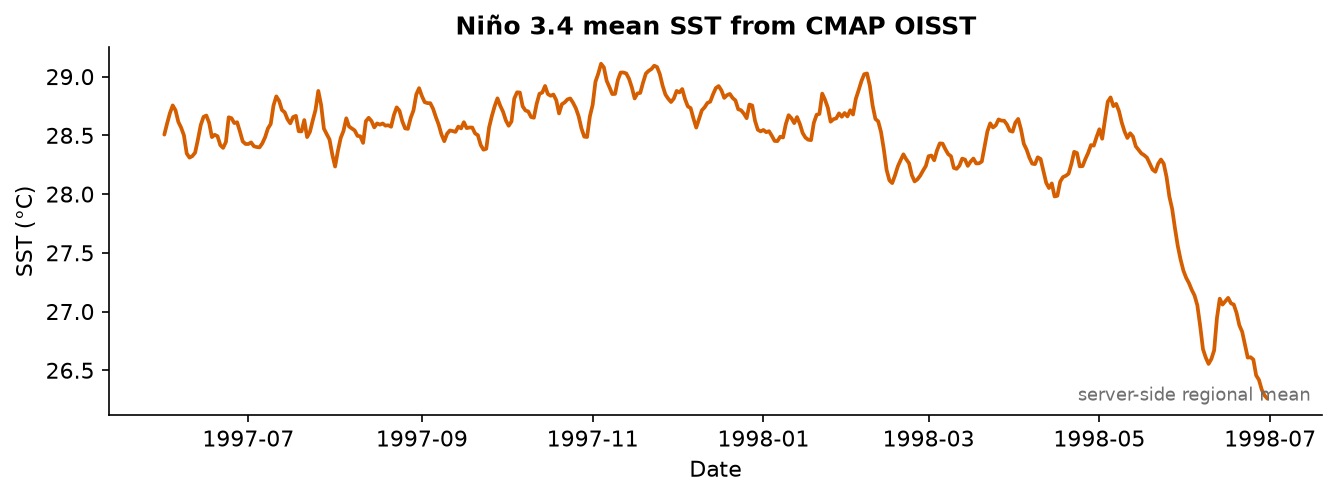

In [160]:
ts = api.time_series(
    table="tblSST_AVHRR_OI_NRT",
    variable="sst",
    dt1="1997-06-01",
    dt2="1998-06-30",
    lat1=-5,
    lat2=5,
    lon1=-170,
    lon2=-120,
    depth1=0,
    depth2=0,
)
ts["time"] = pd.to_datetime(ts["time"])
fig, ax = plt.subplots(figsize=(8.8, 3.2), layout="constrained")
ax.plot(ts.time, ts.sst, color=C["vermillion"], lw=1.8)
ax.set_xlabel("Date")
ax.set_ylabel("SST (°C)")
ax.set_title("Niño 3.4 mean SST from CMAP OISST")
ax.text(
    0.99,
    0.04,
    "server-side regional mean",
    transform=ax.transAxes,
    ha="right",
    color=C["gray"],
    fontsize=8.8,
)
savepub(fig, "api_timeseries_nino34")
plt.show()

## 5. Push computation to the data

A read-only SQL aggregation can be much cheaper than transferring millions of rows. Here the BCI census is reduced to ten species counts on the server.


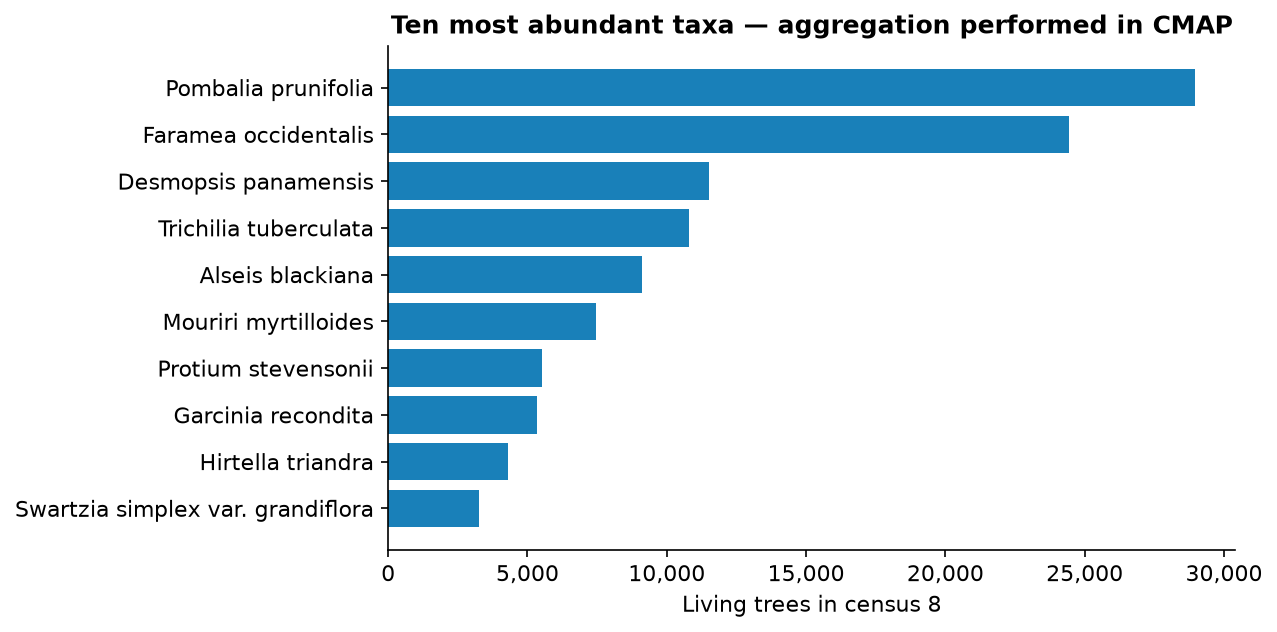

In [161]:
top = api.query("""
    SELECT TOP 10 latin, COUNT(*) AS n_trees
    FROM tblBCI_Census
    WHERE census = 8 AND status LIKE 'A%'   -- 'A' plus rare alive variants (AD, AM, AR)
    GROUP BY latin
    ORDER BY n_trees DESC
""")
fig, ax = plt.subplots(figsize=(8.4, 4.1), layout="constrained")
d = top.sort_values("n_trees")
ax.barh(d.latin, d.n_trees, color=C["blue"], alpha=0.9)
ax.set_xlabel("Living trees in census 8")
ax.set_title("Ten most abundant taxa — aggregation performed in CMAP")
ax.xaxis.set_major_formatter(mpl.ticker.StrMethodFormatter("{x:,.0f}"))
savepub(fig, "api_sql_top_species")
plt.show()

## 6. Colocalize heterogeneous datasets

`pycmap.Sample` treats a source dataframe as space–time observations and samples target datasets at those locations. The operation that augments a cruise track can also augment a forest observation table.


In [162]:
# Tolerances are [days, deg latitude, deg longitude, meters depth] around each source point.
targets = {
    "tblERA5_monthly_averaged_single_level": {
        "variables": ["tp", "aluvp", "tcc"],
        "tolerances": [15, 0.25, 0.25, 0],
    },
    "tblModis_CHL_cl1": {"variables": ["chlor_a"], "tolerances": [4, 0.25, 0.25, 0]},
    "tblSST_AVHRR_OI_NRT": {"variables": ["sst"], "tolerances": [0, 0.25, 0.25, 0]},
}
source = api.query("SELECT TOP 10 * FROM tblBCI_Census WHERE time > '2003-01-01'")
source_ncols = source.shape[1]
joined = pycmap.Sample(source=source, targets=targets)
print(f"\nSource columns: {source_ncols} → joined columns: {joined.shape[1]}")
compact(joined, n=10)

Gathering metadata .... 
Sampling starts
Sampling finished                                                                                                    
Source columns: 21 → joined columns: 26


time,lat,lon,tree_id,stem_id,tag,census,sp_mnemonic,latin,family,quadrat,gx,gy,dbh,hom,status,codes,nostems,agb,ba,date_source,CMAP_tp_tblERA5_monthly_averaged_single_level_avg,CMAP_aluvp_tblERA5_monthly_averaged_single_level_avg,CMAP_tcc_tblERA5_monthly_averaged_single_level_avg,CMAP_chlor_a_tblModis_CHL_cl1_avg,CMAP_sst_tblSST_AVHRR_OI_NRT_avg
2005-01-03T00:00:00,9.151256,-79.855148,226472,226472,255001,6,poular,Poulsenia armata,Moraceae,100,20.200001,1.500000,nan,nan,D,nan,0,0.000000,0.000000,measured,0.003310,0.036461,0.512283,1.459130,27.650000
2005-01-03T00:00:00,9.151334,-79.854774,327245,327245,603013,6,acaldi,Acalypha diversifolia,Euphorbiaceae,300,61.099998,10.300000,21.000000,1.300000,A,nan,1,0.000365,0.000346,measured,0.003310,0.036461,0.512283,1.459130,27.650000
2005-01-03T00:00:00,9.151621,-79.854713,271017,271017,403080,6,alsebl,Alseis blackiana,Rubiaceae,302,67.900002,42.099998,13.000000,1.300000,A,nan,1,0.000213,0.000133,measured,0.003310,0.036461,0.512283,1.459130,27.650000
2005-01-03T00:00:00,9.151740,-79.855095,226927,226927,255462,6,protte,Protium tenuifolium subsp. sessiliflorum,Burseraceae,102,25.600000,55.099998,42.000000,1.300000,A,nan,1,0.003913,0.001385,measured,0.003310,0.036461,0.512283,1.459130,27.650000
2005-01-04T00:00:00,9.151251,-79.855118,326562,326562,601700,6,soroaf,Sorocea affinis,Moraceae,100,23.100000,1.000000,16.000000,1.300000,A,nan,1,0.000389,0.000201,measured,0.003310,0.036461,0.512283,1.459130,27.430000
2005-01-04T00:00:00,9.151259,-79.855309,230848,1014919,260001,6,oenoma,Oenocarpus mapora,Arecaceae,0,2.700000,1.900000,92.000000,1.300000,A,nan,9,0.226789,0.043135,measured,0.003310,0.036461,0.512283,1.459130,27.430000
2005-01-04T00:00:00,9.151270,-79.855118,226484,226484,255013,6,gar2ma,Garcinia madruno,Clusiaceae,100,23.500000,3.100000,21.000000,1.300000,A,nan,1,0.000885,0.000346,measured,0.003310,0.036461,0.512283,1.459130,27.430000
2005-01-04T00:00:00,9.151271,-79.855148,226474,226474,255003,6,faraoc,Faramea occidentalis,Rubiaceae,100,20.299999,3.200000,nan,nan,D,nan,0,0.000000,0.000000,measured,0.003310,0.036461,0.512283,1.459130,27.430000
2005-01-04T00:00:00,9.151276,-79.855141,226475,226475,255004,6,protco,Protium costaricense,Burseraceae,100,20.600000,3.800000,157.000000,1.300000,A,nan,1,0.127309,0.019359,measured,0.003310,0.036461,0.512283,1.459130,27.430000
2005-01-04T00:00:00,9.151280,-79.855141,226476,925885,255005,6,hybapr,Pombalia prunifolia,Violaceae,100,21.100000,4.300000,17.000000,1.300000,A,nan,2,0.000694,0.000340,measured,0.003310,0.036461,0.512283,1.459130,27.430000


## 7. Why this matters

The API is not the scientific contribution by itself. The value comes from the layers underneath it:

**curation + harmonization + common identifiers + server-side computation + reusable interfaces**

Those layers make the BCI case study reproducible and provide the substrate for future genomic/metabolomic integration.


## Data sources

- Condit R, Pérez R, Aguilar S, Lao S, Foster RB, Hubbell SP (2019). *Complete data from the Barro Colorado 50-ha plot: 423617 trees, 35 years.* Dryad. doi:10.15146/5xcp-0d46 (CC0). The Dryad deposit is the version approved by the lead investigators, who ask to be informed of resulting work.
- Paton S. *Monthly Summary_BCI, Vertical.* Smithsonian Tropical Research Institute, Physical Monitoring Program. doi:10.25573/data.10059458 (CC BY).
- Hersbach H, et al. (2020). *The ERA5 global reanalysis.* Q. J. R. Meteorol. Soc. 146, 1999–2049. ECMWF / Copernicus Climate Change Service.
- Huang B, et al. (2021). *Improvements of the Daily Optimum Interpolation Sea Surface Temperature (DOISST) Version 2.1.* J. Climate 34, 2923–2939 (NOAA OISST v2.1).
- NASA MODIS Aqua ocean color (chlorophyll-a).
